In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean as cm
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2

from datetime import timedelta
from scipy.interpolate import griddata
from tqdm.notebook import tqdm

In [2]:
path_model = '/media/drdarby/Elements/data/Thesis/LLC4320/3d_Cruise_cutout/'
variable = ['Theta','Salt','W']

In [3]:
files,pathfiles = tools.get_data_paths_from_binary(path_model,variable[0],file_end='79')
files_salt,pathfiles_salt = tools.get_data_paths_from_binary(path_model,variable[1],file_end='79')
files_w,pathfiles_w = tools.get_data_paths_from_binary(path_model,variable[2],file_end='79')

In [4]:
oned_grid_files,oned_grid_pathfiles = tools.get_data_paths_from_binary(path_model,'grid',delim='_',file_end='79')
twod_grid_files,twod_grid_pathfiles = tools.get_data_paths_from_binary(path_model,'grid',delim='x',file_end='138')

In [5]:
twod_grid_pathfiles[-4]

'/media/drdarby/Elements/data/Thesis/LLC4320/3d_Cruise_cutout/grid/XC_122x138'

In [6]:
twod_grid_pathfiles[-2]


'/media/drdarby/Elements/data/Thesis/LLC4320/3d_Cruise_cutout/grid/YC_122x138'

In [7]:
shape1 = (79)
shape2 = (138,122)
RC = np.fromfile(oned_grid_pathfiles[1],'>f4')
RC = np.reshape(RC,shape1)
Lat = np.fromfile(twod_grid_pathfiles[-2],'>f4')
Lat = np.reshape(Lat, shape2)
Lon = np.fromfile(twod_grid_pathfiles[-4],'>f4')
Lon = np.reshape(Lon, shape2)

In [8]:
iter_date = []
for i in range(0,len(files)):
    convert_date = tools.convert_itter_to_datetime(files[i][0:10],datetime(2011,9,10),25)
    iter_date.append(convert_date)

In [2]:
path_obs = 'D:/data/Thesis/gliders/cruise/swfscTrinidadCTD_5993_df58_8d33.nc'
data_obs = xr.open_dataset(path_obs)

In [4]:
data_obs['depth'].max()

<xarray.DataArray 'depth' ()> Size: 8B
array(493.)

In [19]:
(-124.75783333-.5, -124.20275+.5) 
(41.0537-.5, 41.06663333+.5)

(40.5537, 41.56663333)

In [20]:
time_obs = np.array(data_obs.time).ravel()
time_obs = time_obs[np.isfinite(time_obs)]

/home/drdarby/miniconda3/envs/mitgcm/lib/python3.11/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [10]:
#tools.convert_mitgcm_grid_to_nc(path_model+'grid',(122,138,79),output_path='./cruise_cutout_grid.nc')

In [21]:
data_time = []
for i in range(0,len(time_obs)):
    year, month, day, hour = str(time_obs[i])[:4],str(time_obs[i])[5:7],str(time_obs[i])[8:10],str(time_obs[i])[11:13]
    data_time.append(datetime(int(year),int(month),int(day),int(hour)))

In [22]:
indices_model_from_obs = np.intersect1d(iter_date,data_time,return_indices=True)[1]

model_at_obs_dates = np.array(pathfiles)[indices_model_from_obs]

In [23]:
model_at_obs_dates_salt = np.array(pathfiles_salt)[indices_model_from_obs]

In [24]:
model_at_obs_dates_w = np.array(pathfiles_w)[indices_model_from_obs]

In [25]:
intersect_dates = np.intersect1d(iter_date,data_time,return_indices=True)[0]

In [10]:
i0 = np.arange(122)
j0 = np.arange(138)
k0 = np.arange(79)
for i in tqdm(range(0,len(iter_date))):
    time = [iter_date[i]]
    shape = (1,79,138,122)
    file = np.fromfile(pathfiles[i],'>f4')
    file = np.reshape(file, shape)
    data = xr.DataArray(file, dims=['time','depths','j','i'], coords = [time,RC,j0,i0],name='Theta')
    data.to_netcdf(path_model+'nc_files/Theta/Theta_cruise_'+str(i).zfill(4)+'.nc')


  0%|          | 0/9121 [00:00<?, ?it/s]

In [17]:
grid = grid.rename({'i':'i0','j':'j0'}).rename({'i0':'j','j0':'i'})

NameError: name 'grid' is not defined

In [35]:
sub_files,sub_pathfiles = tools.get_data_paths_from_binary(path_model,'time-subsample/',file_end='nc')

In [36]:
sub_files_salt,sub_pathfiles_salt = tools.get_data_paths_from_binary(path_model,'time-subsample-salt/',file_end='nc')

In [37]:
sub_files_w,sub_pathfiles_w = tools.get_data_paths_from_binary(path_model,'time-subsample-w/',file_end='nc')

In [38]:
model_sub = xr.open_mfdataset(sub_pathfiles)

In [39]:
model_sub_salt = xr.open_mfdataset(sub_pathfiles_salt)

In [40]:
model_sub_w = xr.open_mfdataset(sub_pathfiles_w)

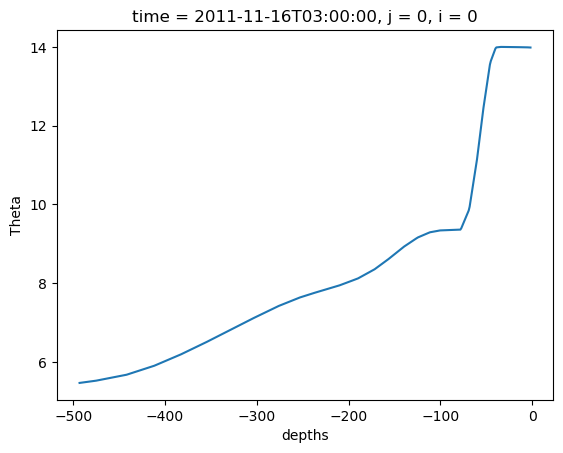

In [59]:
model_sub['Theta'].interp(depths=depth_range*-1).isel(time=0,i=0,j=0).plot()

In [36]:
#data_obs.latitude
#data_obs.longitude
#data_obs['temperature'].sel(trajectory=1).dropna(dim='profile',how='all').dropna(dim='obs',how='all').plot()



In [60]:
# #np.max(Lat)
# np.max(Lat)

#(obs_lat)[np.isfinite(obs_lat)]

42.056038

In [26]:
# absi = np.abs(Lat-obs_lat[0])
# absj = np.abs(Lon-(obs_lon[0]-360))
# c = np.maximum(absj, absi)
# c

NameError: name 'obs_lat' is not defined

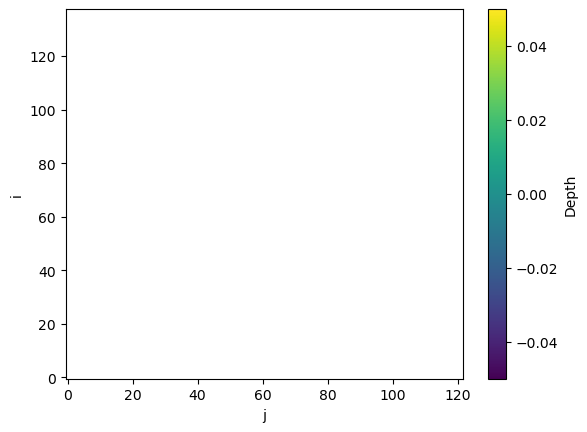

In [27]:
#get list of points
obs_lat, obs_lon = np.array(data_obs['latitude']).ravel(),np.array(data_obs['longitude']).ravel()
points_i = []
points_j = []
points_tuple = [] 
for k in range(0,len(obs_lat)):
    absi = np.abs(Lat.T-obs_lat[k])
    absj = np.abs(Lon.T-(obs_lon[k]-360))
    c = np.maximum(absj, absi)
    xloc, yloc = np.where(c == np.min(c))
    if len(xloc)==1:
        ind = xloc[0], yloc[0]
        points_tuple.append(ind)
        points_i.append(ind[1])
        points_j.append(ind[0])
    if len(xloc)!=1:
        points_i.append(0)
        points_j.append(0)
   
        
# for h in range(0,len(list(dict.fromkeys(points_tuple)))):
#     tups = list(dict.fromkeys(points_tuple))[h]
#     points_i.append(tups[1])
#     points_j.append(tups[0])


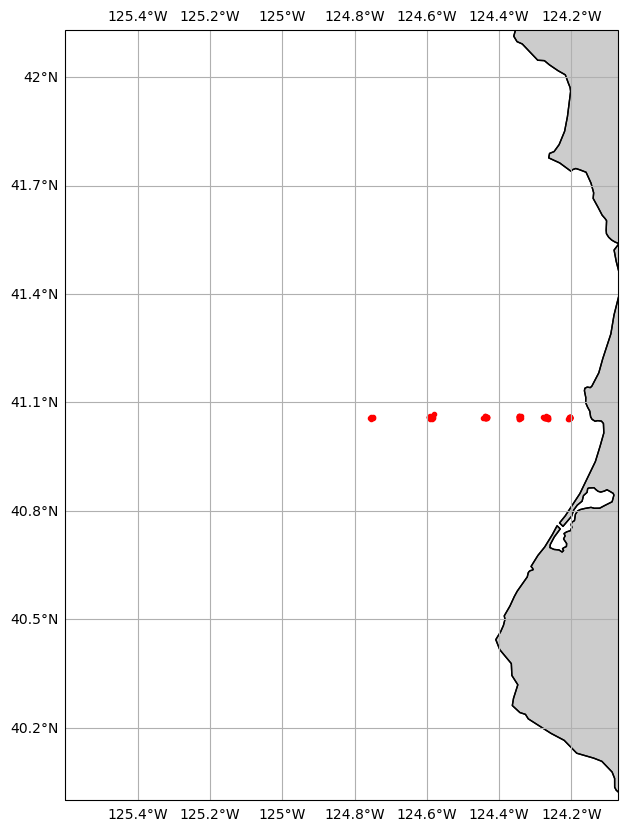

In [118]:
plt.figure(figsize=(10,10))
grid = grid.set_coords({'XC','YC'})
proj = ccrs.PlateCarree()

ax = plt.axes(projection=proj)

#grid.Depth.plot(x='XC',y='YC',transform=ccrs.PlateCarree(),ax=ax,cmap=cm.cm.deep) #.isel(i=slice(0,150),j=slice(145,270))
# plt.plot(grid.Depth.XC[:,0],grid.Depth.YC[:,0],'r.',transform=ccrs.PlateCarree())
# plt.plot(grid.Depth.XC[:,-1],grid.Depth.YC[:,-1],'r.',transform=ccrs.PlateCarree())
# plt.plot(grid.Depth.XC[0,:],grid.Depth.YC[0,:],'r.',transform=ccrs.PlateCarree())
# plt.plot(grid.Depth.XC[-1,:],grid.Depth.YC[-1,:],'r.',transform=ccrs.PlateCarree())
plt.plot(obs_lon, obs_lat,'r.',transform=ccrs.PlateCarree())
#plt.plot(grid.Depth.XC[0,:],grid.Depth.YC[:,0],'r.',transform=ccrs.PlateCarree())
#plt.plot(grid.Depth.XC[:,0],grid.Depth.YC[0,:],'r.',transform=ccrs.PlateCarree())
plt.xlim

coast_10m = cfeature.NaturalEarthFeature("physical", "land", "10m", edgecolor="k", facecolor="0.8")
ax.add_feature(coast_10m)
ax.coastlines()
ax.set_extent([-125.6,-124.07,40,42.13])
gl = ax.gridlines(draw_labels=True)
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.right_labels=False

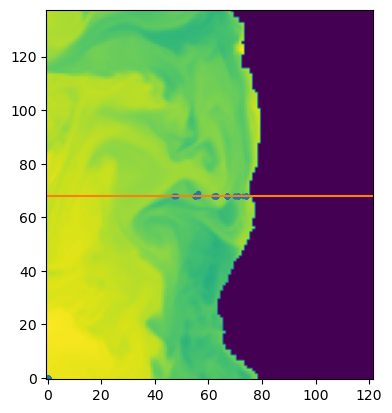

In [34]:

shape = (79,138,122)


file = np.fromfile(model_at_obs_dates[-20],'>f4')
file = np.reshape(file, shape)

plt.imshow(file[0,:,:])
plt.plot(np.array(points_j),np.array(points_i),'.')
plt.plot(np.arange(122),[68]*122)
plt.gca().invert_yaxis()

NameError: name 'm' is not defined

In [81]:
depth_range = np.linspace(2,np.array(data_obs.depth.max()),490)
tot = 0
for m in tqdm(range(0,len(data_obs.trajectory))):
    for n in range(0,len(data_obs.profile)):
        if np.reshape(points_i,(17,6))[m][n]!=0:
            corr_i = int(np.reshape(points_j,(17,6))[m][n])
            corr_j = int(np.reshape(points_i,(17,6))[m][n])
            depth_range = np.linspace(2,np.array(data_obs.depth.max()),490)
            obs_depth = data_obs['depth'].sel(trajectory=m,profile=n).dropna(dim='obs',how='any')
            obs_temp = data_obs['temperature'].sel(trajectory=m,profile=n).dropna(dim='obs',how='any')
            obs_salt = data_obs['salinity'].sel(trajectory=m,profile=n).dropna(dim='obs',how='any')

            temp_fix = np.interp(depth_range,obs_depth,obs_temp,left=np.nan,right=np.nan)
            salt_fix = np.interp(depth_range,obs_depth,obs_salt,left=np.nan,right=np.nan)
            SA = model_sub_salt['Salt'].interp(depths=depth_range*-1,method='nearest').isel(time=tot,i=corr_i,j=corr_j)
            pot_temp_obs = gsw.pt_from_t(SA,temp_fix,depth_range,0)
            pot_temp_obs = pot_temp_obs.rename('Theta_obs')
            pot_temp_model = model_sub['Theta'].interp(depths=depth_range*-1,method='nearest').isel(time=tot,i=corr_i,j=corr_j)
            pot_temp_model['longitude']=np.array(data_obs['longitude'].sel(trajectory=m,profile=n))-360
            pot_temp_model['cruise']=m

            salt_obs = xr.DataArray(salt_fix, dims=['depths'],coords=[depth_range*-1],name='Salt_obs')
            salt_obs['i'] = pot_temp_model.i
            salt_obs['j'] = pot_temp_model.j
            salt_obs['time'] = pot_temp_model.time

            w_model = model_sub_w['w'].interp(depths=depth_range*-1,method='nearest').isel(time=tot,i=corr_i,j=corr_j)

            total_model_obs = xr.merge([pot_temp_model,SA,pot_temp_obs,salt_obs,w_model]).where(depth_range>np.array(obs_depth)[-1]*-1)
            total_model_obs.to_netcdf(path_model+'model_and_obs/cruise_subsample_'+str(tot).zfill(4)+'.nc')
            tot=tot+1

  0%|          | 0/17 [00:00<?, ?it/s]

IndexError: Index 77 is out of bounds for axis 0 with size 77

In [40]:
pot_temp_model
pot_temp_model['longitude']=np.array(data_obs['longitude'].sel(trajectory=m,profile=n))-360
pot_temp_model['cruise']=m

total_model_obs = xr.merge([pot_temp_model,SA,pot_temp_obs,salt_obs,w_model]).where(depth_range>np.array(obs_depth)[-1]*-1)


In [97]:
Lon[50,:]

array([-125.739586, -125.71875 , -125.697914, -125.677086, -125.65625 ,
       -125.635414, -125.614586, -125.59375 , -125.572914, -125.552086,
       -125.53125 , -125.510414, -125.489586, -125.46875 , -125.447914,
       -125.427086, -125.40625 , -125.385414, -125.364586, -125.34375 ,
       -125.322914, -125.302086, -125.28125 , -125.260414, -125.239586,
       -125.21875 , -125.197914, -125.177086, -125.15625 , -125.135414,
       -125.114586, -125.09375 , -125.072914, -125.052086, -125.03125 ,
       -125.010414, -124.989586, -124.96875 , -124.947914, -124.927086,
       -124.90625 , -124.885414, -124.864586, -124.84375 , -124.822914,
       -124.802086, -124.78125 , -124.760414, -124.739586, -124.71875 ,
       -124.697914, -124.677086, -124.65625 , -124.635414, -124.614586,
       -124.59375 , -124.572914, -124.552086, -124.53125 , -124.510414,
       -124.489586, -124.46875 , -124.447914, -124.427086, -124.40625 ,
       -124.385414, -124.364586, -124.34375 , -124.322914, -124.

(-124.7, -124.25)

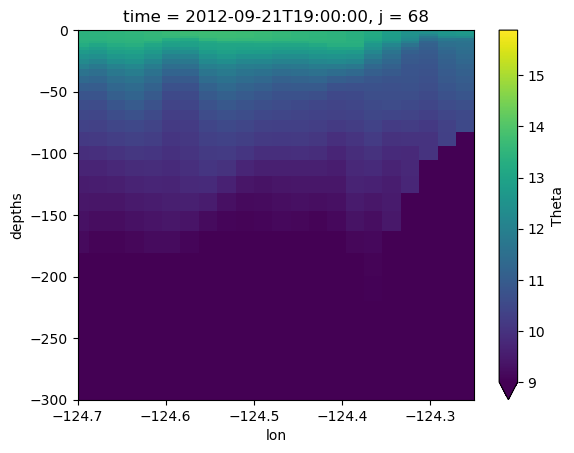

In [103]:
model_sub['i'] = Lon[50,:]
#model_sub = model_sub.rename({'i':'lon'})
model_sub['Theta'].sel(j=68).sel(time='2012-09-21 19').plot(vmin=9)
#plt.plot(points_j,[-10]*len(points_j))
plt.ylim(-300,0)
plt.xlim(-124.7,-124.25)

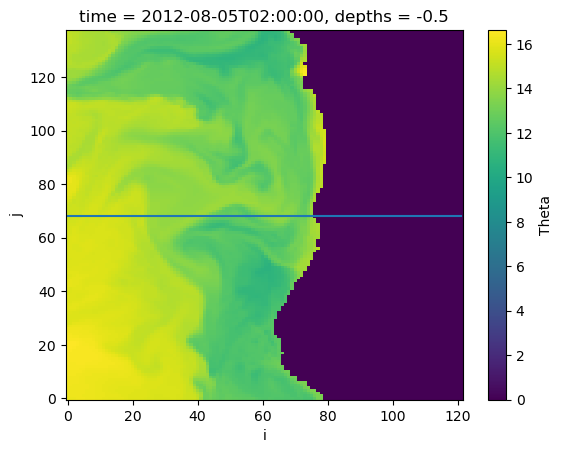

In [66]:
model_sub['Theta'].isel(time=55,depths=0).plot()
plt.plot(np.arange(122),[68]*122)


In [3]:
files_total,pathfiles_total = tools.get_data_paths_from_binary(path_model,'model_and_obs',file_end='nc')

In [4]:
model_and_obs = xr.open_mfdataset(pathfiles_total,combine='nested',concat_dim='time')

In [80]:
model_and_obs.close()

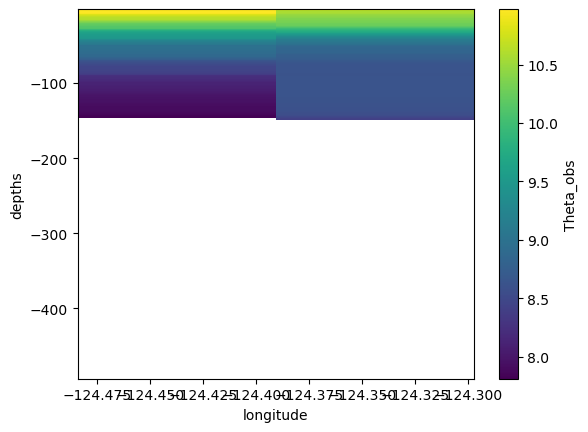

In [12]:
cruise_num=0
model_and_obs.where(model_and_obs['cruise']==cruise_num).sortby('longitude')['Theta_obs'].dropna(dim='time',how='all').plot(y='depths',x='longitude')

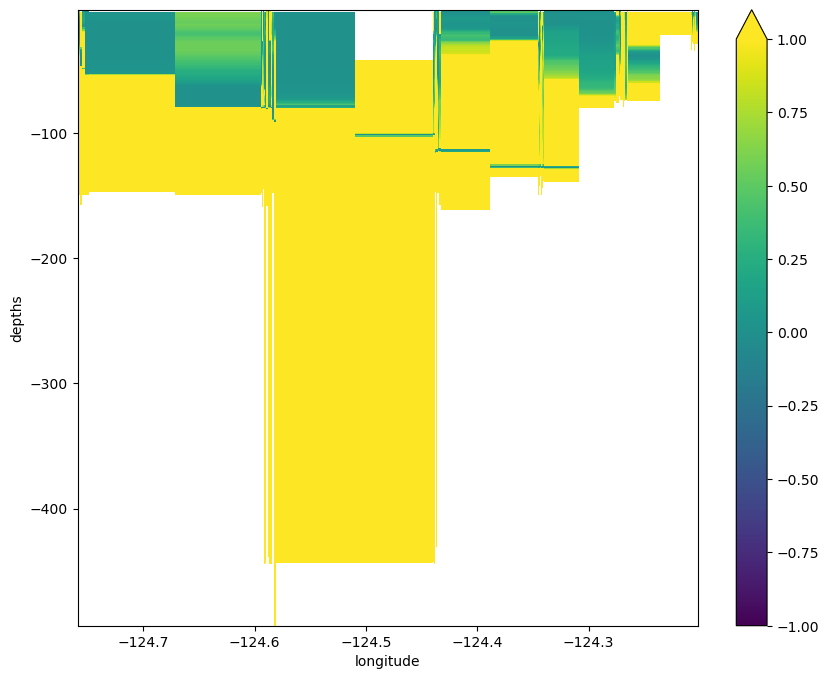

In [114]:
plt.figure(figsize=(10,8))
((model_and_obs['Theta']-model_and_obs['Theta_obs'])**2).sortby('longitude').dropna(dim='time',how='all').plot(y='depths',x='longitude',vmin=-1,vmax=1)
plt.show()

In [69]:
for cruise_num in tqdm(model_and_obs['cruise']):
    fig,ax = plt.subplots(ncols=3, nrows=1,figsize=(10,8))

    obs = model_and_obs.where(model_and_obs['cruise']==cruise_num)['Theta_obs'].sortby('longitude')
    model = model_and_obs.where(model_and_obs['cruise']==cruise_num)['Theta'].where(np.isfinite(obs)).sortby('longitude').dropna(dim='time',how='all')

    obs=obs.dropna(dim='time',how='all')
    obs.plot(vmin=np.array(obs.min().round()),vmax=np.array(obs.max().round()),x='longitude',y='depths',ax=ax[0])
    model = model.where(model>0)
    model.plot(vmin=np.array(obs.min().round()),vmax=np.array(obs.max().round()),x='longitude',y='depths',ax=ax[1])
    (model-obs).plot(x='longitude',y='depths',ax=ax[2], cmap=cm.cm.balance)
    cruise_ind = np.where(model_and_obs['cruise']==cruise_num)[0]
    date = str(np.array(model_and_obs.isel(time=cruise_ind).time)[0])[:13]
    ax[0].set_title('Obs. Pot. Temp. \n date = ' +date)
    ax[1].set_title('cruise = '+ str(np.array(cruise_num)) +'\n Model Pot. Temp.')
    ax[2].set_title('Obs-Model Pot. Temp.')
    ax[0].tick_params(labelrotation=45)

    ax[1].tick_params(labelrotation=45)
    ax[2].tick_params(labelrotation=45)
    plt.tight_layout()

    plt.savefig('./data/Cruise_comparison/cruise_comp_'+str(np.array(cruise_num))+'.png')
    plt.close()

  0%|          | 0/77 [00:00<?, ?it/s]

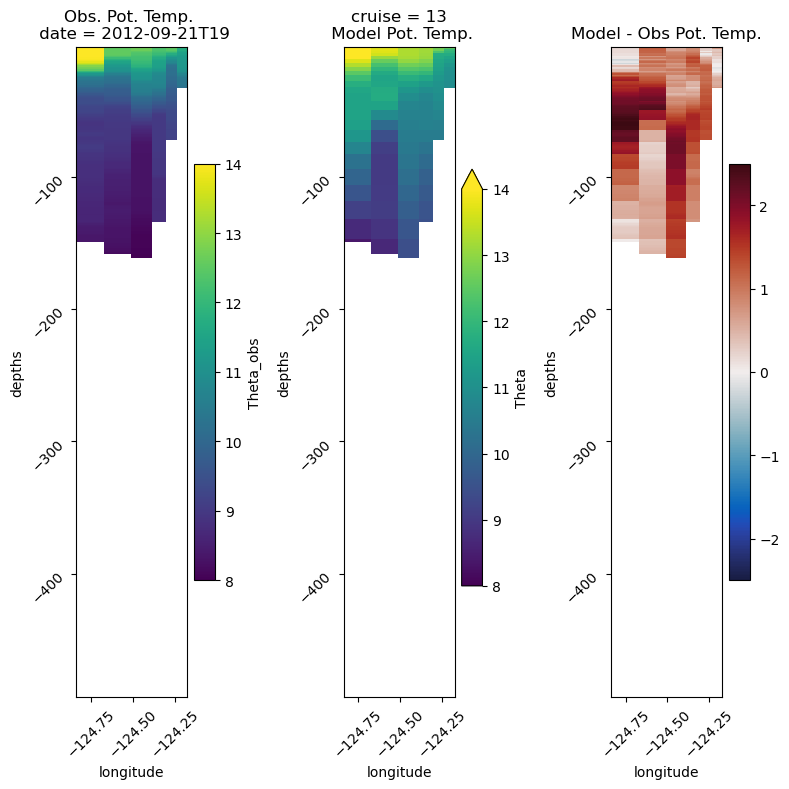

In [68]:
cruise_num = model_and_obs['cruise'][2]

cruise_num=13
fig,ax = plt.subplots(ncols=3, nrows=1,figsize=(8,8),sharex=True)

obs = model_and_obs.where(model_and_obs['cruise']==cruise_num)['Theta_obs'].sortby('longitude')
model = model_and_obs.where(model_and_obs['cruise']==cruise_num)['Theta'].where(np.isfinite(obs)).sortby('longitude').dropna(dim='time',how='all')

obs=obs.dropna(dim='time',how='all')
obs.plot(vmin=np.array(obs.min().round()),vmax=np.array(obs.max().round()),x='longitude',y='depths',ax=ax[0])
ax[0].tick_params(labelrotation=45)

ax[1].tick_params(labelrotation=45)
ax[2].tick_params(labelrotation=45)

model = model.where(model>0)
model.plot(vmin=np.array(obs.min().round()),vmax=np.array(obs.max().round()),x='longitude',y='depths',ax=ax[1])
(model-obs).plot(x='longitude',y='depths',ax=ax[2], cmap=cm.cm.balance)
cruise_ind = np.where(model_and_obs['cruise']==cruise_num)[0]
date = str(np.array(model_and_obs.isel(time=cruise_ind).time)[0])[:13]
ax[0].set_title('Obs. Pot. Temp. \n date = ' +date)
ax[1].set_title('cruise = '+ str(np.array(cruise_num)) +'\n Model Pot. Temp.')
ax[2].set_title('Model - Obs Pot. Temp.')
plt.tight_layout()
plt.savefig('./data/Cruise_comparison/cruise_comp_'+str(np.array(cruise_num))+'.png',bbox_inches='tight')
#plt.close()

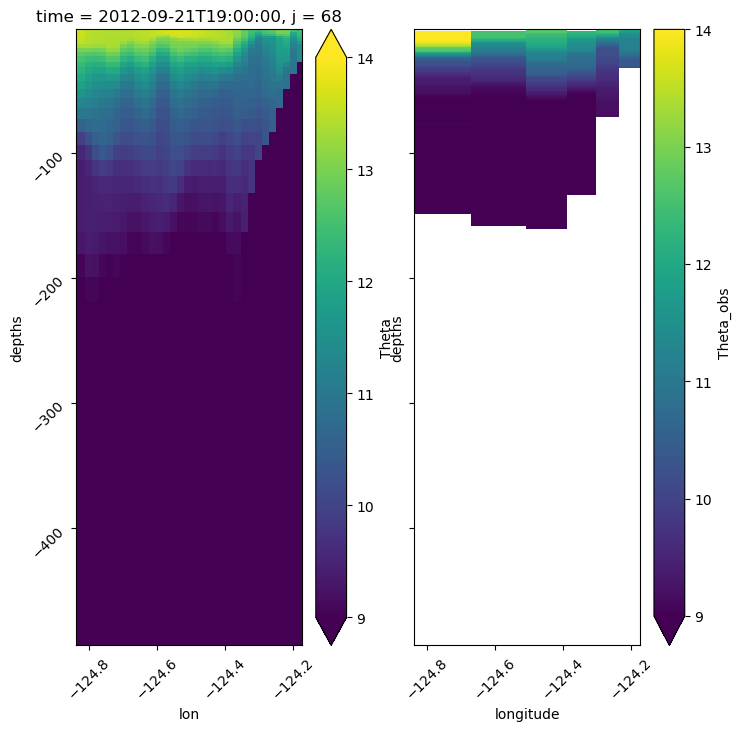

In [132]:
fig,ax = plt.subplots(ncols=2, nrows=1,figsize=(8,8),sharey=True,sharex=True)

model_sub['i'] = Lon[50,:]
#model_sub = model_sub.rename({'i':'lon'})
model_sub['Theta'].sel(j=68).sel(time='2012-09-21 19').plot(vmin=9,vmax=14,ax=ax[0])
#plt.plot(points_j,[-10]*len(points_j))
ax[0].set_ylim(-300,0)
ax[1].set_ylim(-300,0)
#ax[1].set_yticks([0,-50,-100,-150,-200,-250,-300])

ax[0].set_xlim(-124.8,-124.25)
obs.plot(vmin=9,vmax=np.array(obs.max().round()),x='longitude',y='depths',ax=ax[1])
ax[0].tick_params(labelrotation=45)
ax[1].tick_params(labelrotation=45)


In [57]:
points_model = []
points_obs = []
depths_points = []
cruise = np.unique(model_and_obs['cruise'])
for cruise_num in tqdm(cruise):
    obs = model_and_obs.where(model_and_obs['cruise']==cruise_num)['Theta_obs']
    model = model_and_obs.where(model_and_obs['cruise']==cruise_num)['Theta'].where(np.isfinite(obs))
    
    points_model.append(np.array(model).ravel())
    points_obs.append(np.array(obs).ravel())
    for n in range(0,77):
        depths_points.append(np.array(model.depths))


  0%|          | 0/16 [00:00<?, ?it/s]

In [56]:
np.shape(model.depths)

(490,)

In [42]:
np.linspace(5,14,50)

array([5.])

Text(0.5, 0, 'Observed Potential Temperature [$^\\circ$ C]')

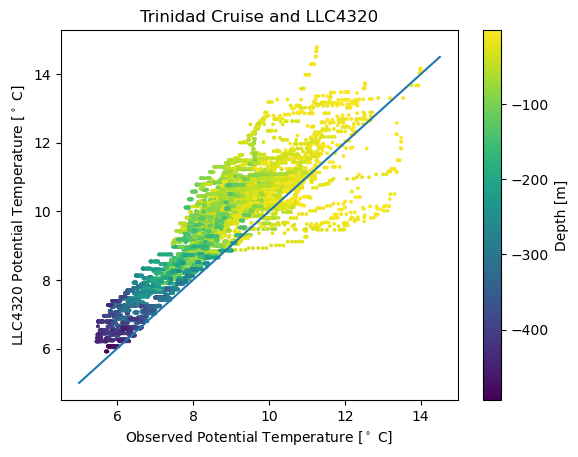

In [63]:
plt.scatter(np.array(points_obs).ravel(),np.array(points_model).ravel(),c=depths_points,s=3)
plt.plot(np.linspace(5,14.5,50),np.linspace(5,14.5,50))
plt.colorbar(label='Depth [m]')
plt.title('Trinidad Cruise and LLC4320')
plt.ylabel('LLC4320 Potential Temperature [$^\circ$ C]')
plt.xlabel('Observed Potential Temperature [$^\circ$ C]')

In [ ]:
### Model Skill



Text(0.5, 1.0, 'Obs-Model Pot. Temp.')

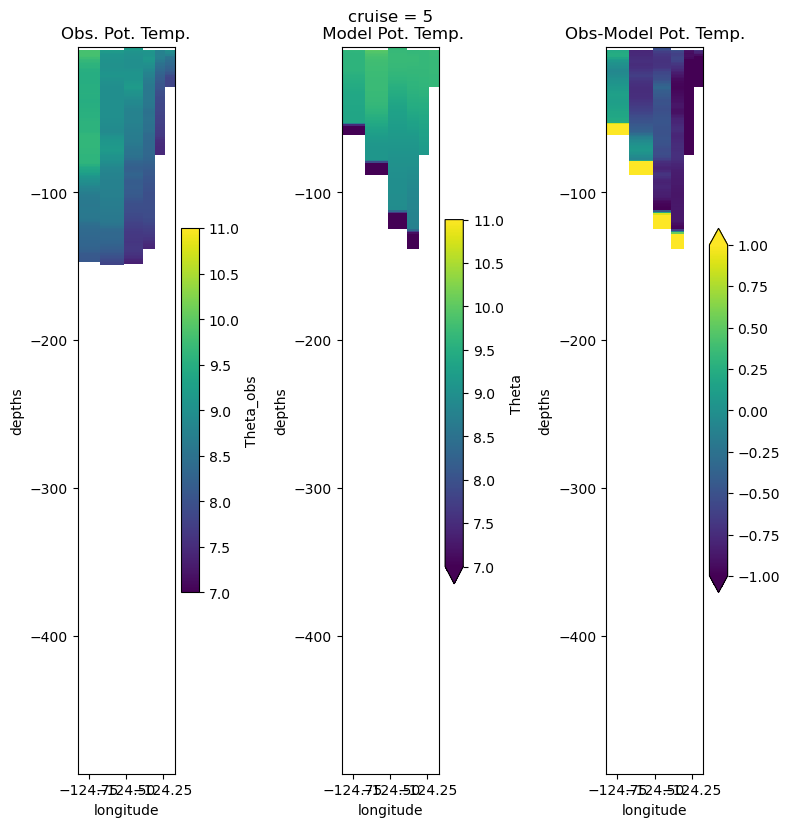

In [30]:
cruise_num=5
fig,ax = plt.subplots(ncols=3, nrows=1,figsize=(8,8))

obs = model_and_obs.where(model_and_obs['cruise']==cruise_num)['Theta_obs'].sortby('longitude')
model = model_and_obs.where(model_and_obs['cruise']==cruise_num)['Theta'].where(np.isfinite(obs)).sortby('longitude').dropna(dim='time',how='all')

obs=obs.dropna(dim='time',how='all')
obs.plot(vmin=7,vmax=11,x='longitude',y='depths',ax=ax[0])
model = model.where(model>0)
model.plot(vmin=7,vmax=11,x='longitude',y='depths',ax=ax[1])
(obs-model).plot(vmin=-1,vmax=1,x='longitude',y='depths',ax=ax[2])
plt.tight_layout()

ax[0].set_title('Obs. Pot. Temp.')
ax[1].set_title('cruise = '+ str(cruise_num) +'\n Model Pot. Temp.')
ax[2].set_title('Obs-Model Pot. Temp.')
plt.save_fig('./data/Cruise_comparison/cruise_comp_'+str(cruise_num)+'.png')

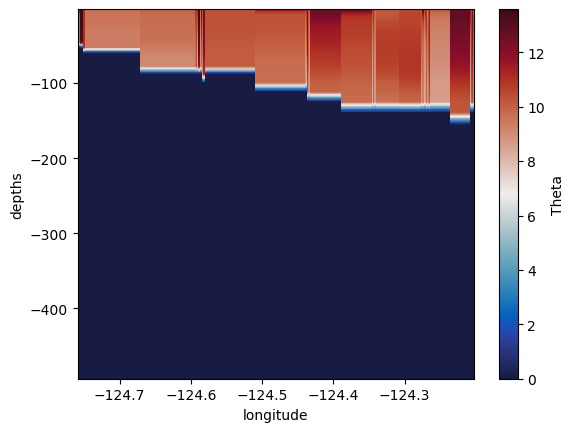

In [121]:
model_and_obs.sortby('longitude')['Theta'].plot(y='depths',x='longitude',cmap=cm.cm.balance)

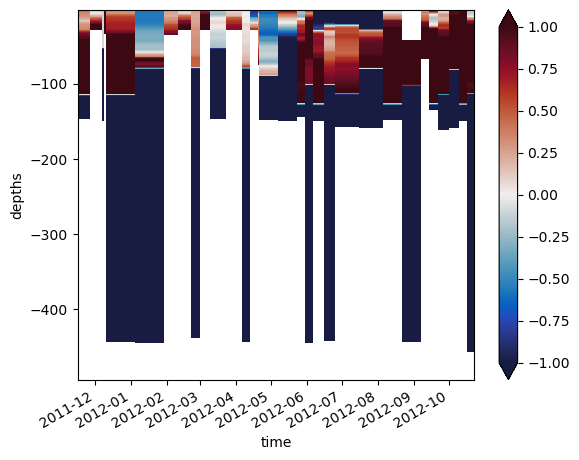

In [54]:
(model_and_obs['Theta']-model_and_obs['Theta_obs']).plot(y='depths',vmin=-1,vmax=1,cmap=cm.cm.balance)

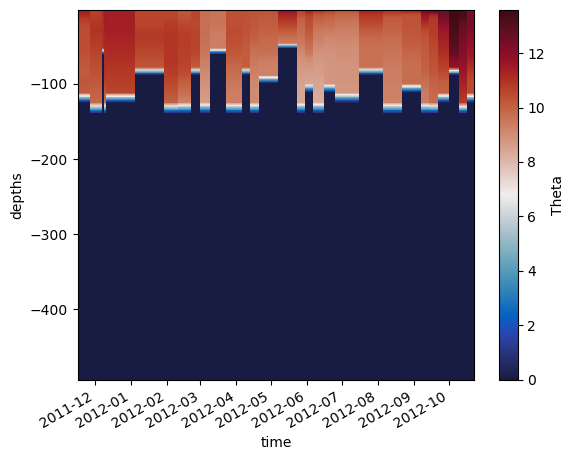

In [117]:
model_and_obs['Theta'].plot(y='depths',cmap=cm.cm.balance)


In [58]:
model_and_obs.sel(cruise=1)

KeyError: "no index found for coordinate 'cruise'"

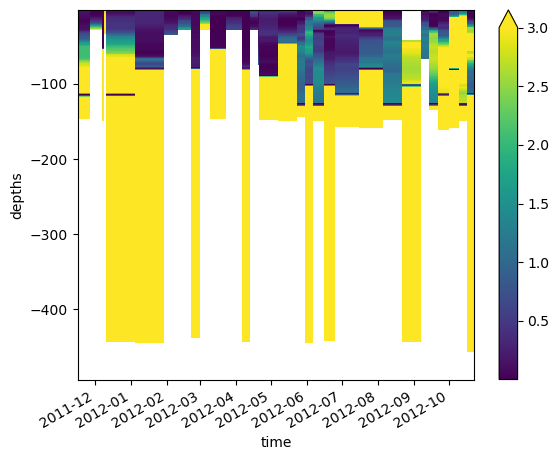

In [56]:
((model_and_obs['Theta']-model_and_obs['Theta_obs'])**2).plot(y='depths',vmax=3)

In [32]:
RC

array([-5.000000e-01, -1.570000e+00, -2.790000e+00, -4.185000e+00,
       -5.780000e+00, -7.595000e+00, -9.660000e+00, -1.201000e+01,
       -1.468000e+01, -1.770500e+01, -2.112500e+01, -2.499000e+01,
       -2.934500e+01, -3.424000e+01, -3.972500e+01, -4.585500e+01,
       -5.269000e+01, -6.028000e+01, -6.868500e+01, -7.796500e+01,
       -8.817500e+01, -9.937000e+01, -1.116000e+02, -1.249150e+02,
       -1.393650e+02, -1.549900e+02, -1.718250e+02, -1.899000e+02,
       -2.092350e+02, -2.298550e+02, -2.517700e+02, -2.749850e+02,
       -2.995050e+02, -3.253200e+02, -3.524200e+02, -3.807900e+02,
       -4.104100e+02, -4.412550e+02, -4.733050e+02, -5.065400e+02,
       -5.409350e+02, -5.764650e+02, -6.131100e+02, -6.508550e+02,
       -6.896850e+02, -7.295950e+02, -7.705850e+02, -8.126600e+02,
       -8.558350e+02, -9.001350e+02, -9.455950e+02, -9.922600e+02,
       -1.040180e+03, -1.089425e+03, -1.140080e+03, -1.192235e+03,
       -1.246005e+03, -1.301520e+03, -1.358920e+03, -1.418375e

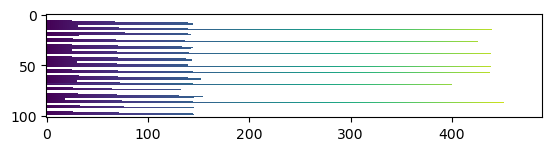

In [89]:
plt.imshow(np.reshape(np.array(data_obs['temperature'].depth),(17*6,490)))#.plot()

In [ ]:
if 

In [37]:
shape = (79,138,122)
file = np.fromfile(model_at_obs_dates[-20],'>f4')
file = np.reshape(file, shape)

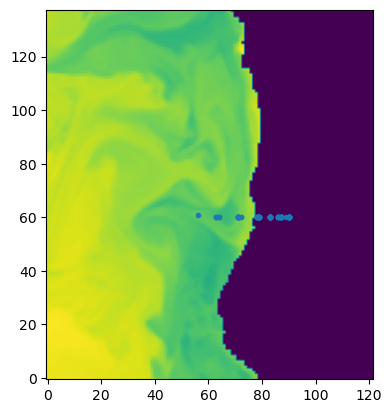

In [117]:
plt.imshow(file[0,:,:])
plt.plot(points_j,points_i,'.')
plt.gca().invert_yaxis()

In [ ]:
# get times the same
#subselect for points in model
# compare profiles.

numpy.datetime64('NaT')

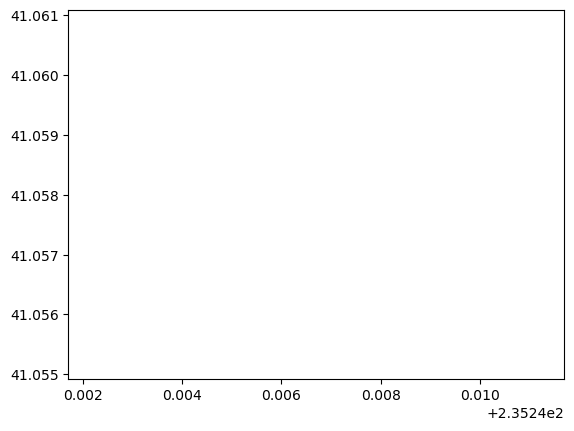

In [89]:
plt.plot(data_obs['longitude'].isel(profile=5),data_obs['latitude'].isel(profile=5))


In [32]:
lat_max = data_obs.latitude.max()
lon_max = data_obs.longitude.max()-360
lat_min = data_obs.latitude.min()
lon_min = data_obs.longitude.min()-360

box = [lon_min,lat_min,lon_max,lat_max]
box

[<xarray.DataArray 'longitude' ()>
 array(-124.75783333),
 <xarray.DataArray 'latitude' ()>
 array(41.0537),
 <xarray.DataArray 'longitude' ()>
 array(-124.20275),
 <xarray.DataArray 'latitude' ()>
 array(41.06663333)]

In [2]:
data_obs

NameError: name 'data_obs' is not defined